В данной работе проводится сравнения результатов расчета напряженно-деформированного состояния (НДС) тонкостенного трубчатого образца при сложном нагружении по винтовой траектории.

**Материал:** Сталь 45 (Модель с несколькими компонентами кинематического упрочнения - **CHAB**).

**Цель:** Анализ векторных и скалярных свойств материала, проверка корректности моделирования в ANSYS.

In [99]:
from core.reader import load_experimental_data
from core.calculations import calculate_von_mises_stress

# CSV лежат в этой же папке, что и ноутбук. Ядро должно иметь cwd = P29/experimental_vint.
# Если cwd — корень репозитория, замените на: real_experiment_data_folder = "P29/experimental_vint"
real_experiment_data_folder = "."
real_experiment = load_experimental_data(real_experiment_data_folder)
real_experiment = calculate_von_mises_stress(
            real_experiment,
            s_x_col="S_TT",
            s_y_col="S_ZZ",
            s_xy_col="S_TZ",
            new_col_name="S_EQV"
        )

### Методика проведения численного эксперимента

Расчет в **ANSYS** выполнялся в деформационном нагружении **поточечно**. Процесс моделирования был организован следующим образом:

*   **Синхронизация по шагам:** На каждом расчетном шаге (step) производилось прямое сопоставление с временной шкалой реального эксперимента.
*   **Граничные условия:** В качестве входных параметров численной модели на каждом шаге использовались компоненты тензора деформаций, полученные непосредственно из экспериментальных данных.
*   **Итерационный расчет:** Программа вычисляла отклик системы (напряжения) для каждой конкретной точки деформационного пути, что позволило обеспечить максимально точное соответствие условий нагружения в модели и в реальности.


In [100]:
from core.reader import read_ansys_csv

numerical_experiment_chab = read_ansys_csv("chab.csv")

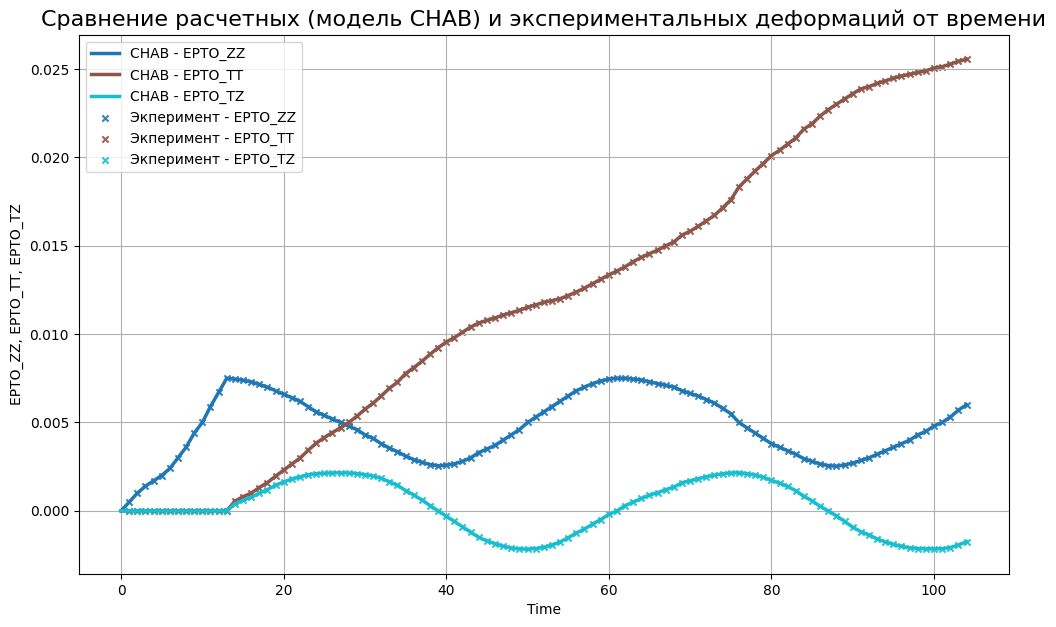

In [101]:
from core.visualizer import plot_xy

model_name = "CHAB"
plot_xy([
        (model_name, numerical_experiment_chab)
    ],
    "Time",
    ["EPTO_ZZ", "EPTO_TT", "EPTO_TZ"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных деформаций от времени",
    ("Экперимент", real_experiment),
    figsize=(12, 7)
)

Построим графики изменения компонент тензора напряжений и интенсивности напряжений от времени.

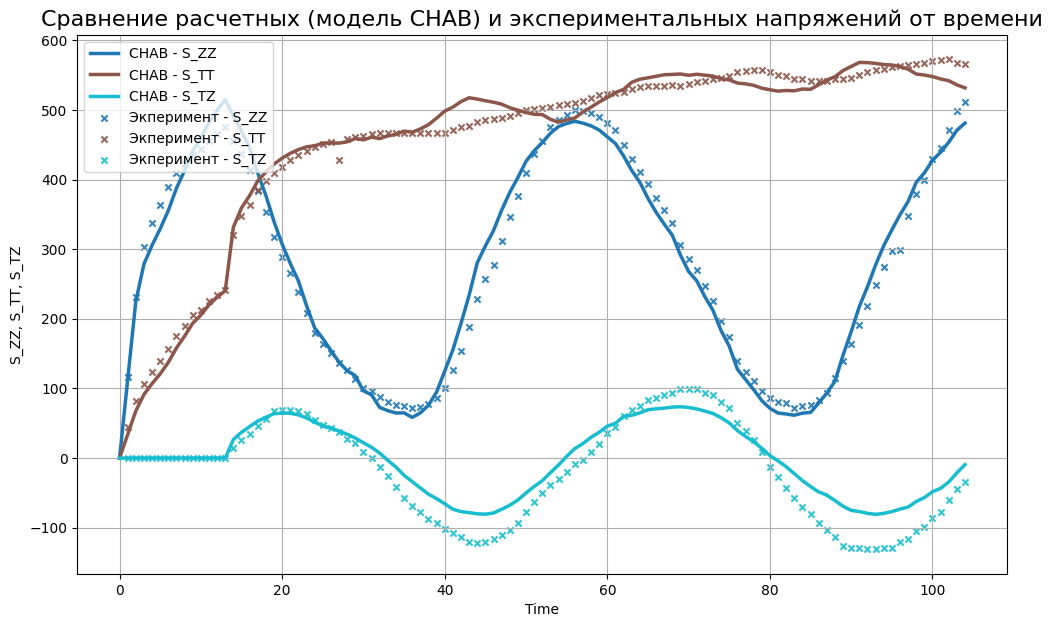

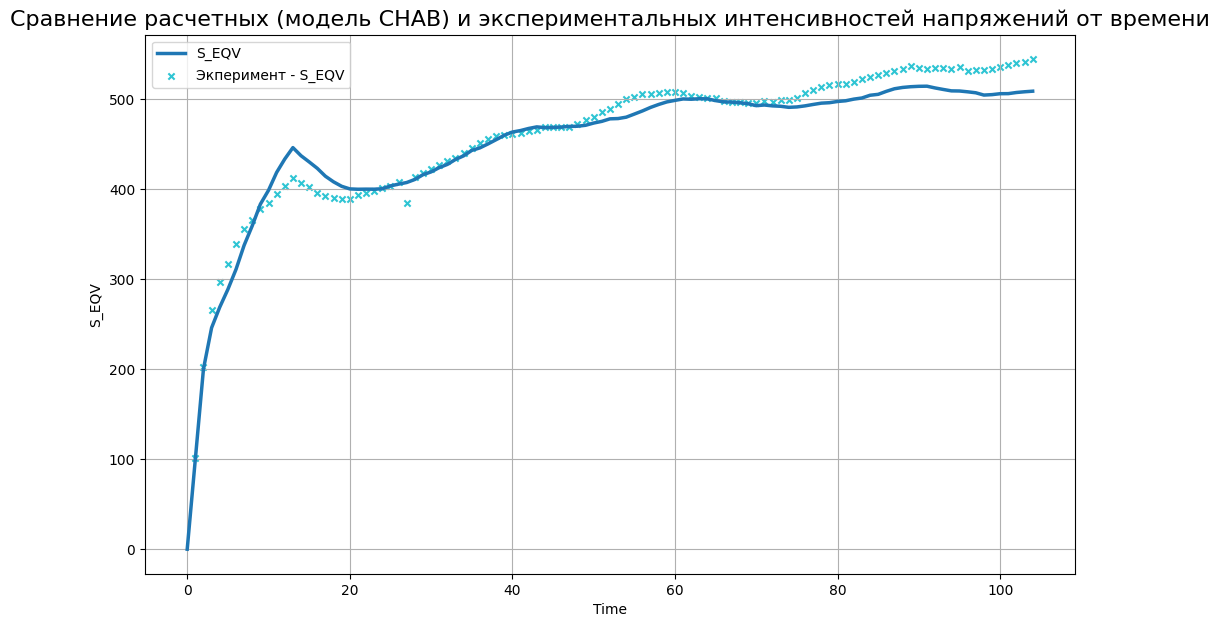

In [102]:
plot_xy([
        (model_name, numerical_experiment_chab)
    ],
    "Time",
    ["S_ZZ", "S_TT", "S_TZ"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных напряжений от времени",
    ("Экперимент", real_experiment),
    figsize=(12, 7)
)

plot_xy([
        (model_name, numerical_experiment_chab)
    ],
    "Time",
    ["S_EQV"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных интенсивностей напряжений от времени",
    ("Экперимент", real_experiment),
    figsize=(12, 7)
)

### Сравнительный анализ в пространстве Ильюшина и длина пути

В пространстве деформаций Ильюшина каждой точке процесса соответствует вектор $(\varepsilon_1^{Il}, \varepsilon_2^{Il}, \varepsilon_3^{Il})$, в пространстве напряжений Ильюшина — вектор $(\sigma_1^{Il}, \sigma_2^{Il}, \sigma_3^{Il})$.

**Длина дуги $s$.** Точки нагружения упорядочены по времени. Между двумя соседними точками задаём приращение
$\Delta\varepsilon_i^{Il} = \varepsilon_i^{Il}(t_{k+1}) - \varepsilon_i^{Il}(t_k)$, $i=1,2,3$.
Евклидова длина шага в пространстве деформаций Ильюшина:
$$\Delta s_k = \sqrt{(\Delta\varepsilon_1^{Il})^2 + (\Delta\varepsilon_2^{Il})^2 + (\Delta\varepsilon_3^{Il})^2}.$$
Накопленная длина пути от начала процесса: $s_0 = 0$, $s_k = \sum_{j=0}^{k-1} \Delta s_j$.

**Какие графики строятся.** Компоненты $\varepsilon_i^{Il}$ и $\sigma_i^{Il}$ от **своей** длины дуги $s$; угол $\varphi$ и относительная разность модулей — в точках эксперимента по времени, абсцисса графиков — экспериментальное $s$.

#### Угол между векторами напряжений Ильюшина ($\varphi$)
$$\varphi = \arccos\left(\frac{\vec{\sigma}^{\mathrm{числ}} \cdot \vec{\sigma}^{\mathrm{эксп}}}{|\vec{\sigma}^{\mathrm{числ}}| \cdot |\vec{\sigma}^{\mathrm{эксп}}|}\right).$$

#### Относительная разность модулей
$$\frac{|\vec{\sigma}^{\mathrm{числ}}| - |\vec{\sigma}^{\mathrm{эксп}}|}{|\vec{\sigma}^{\mathrm{эксп}}|}.$$


In [103]:
from core.calculations import (
    ilushin_stress_metrics_at_experiment_times,
    prepare_ilushin_path_dataset,
)

exp_il = prepare_ilushin_path_dataset(real_experiment, compressible=False)
num_il = prepare_ilushin_path_dataset(numerical_experiment_chab, compressible=True)


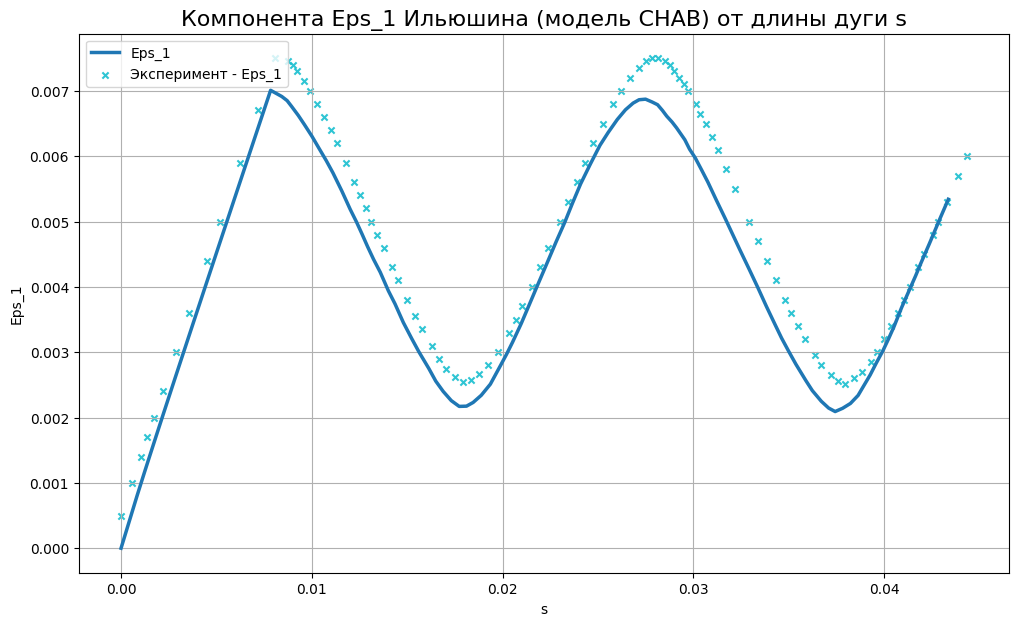

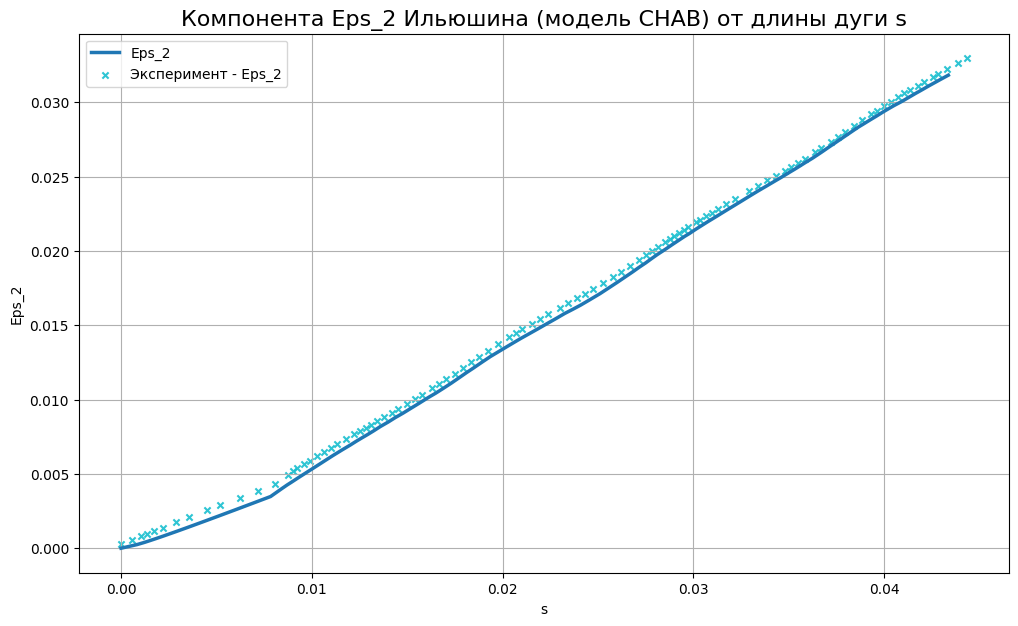

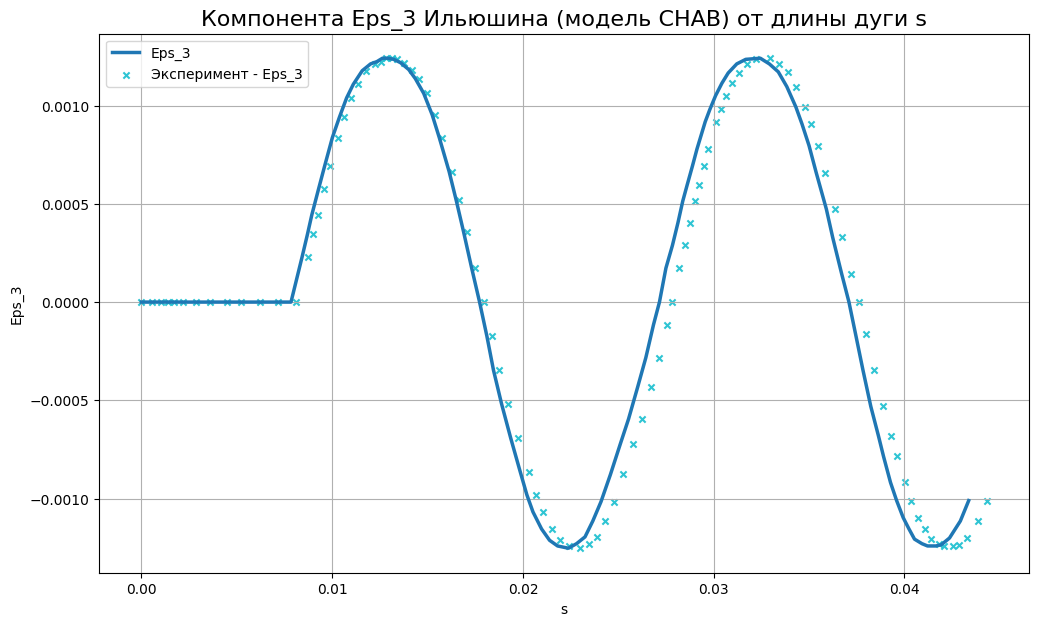

In [104]:
plot_xy(
    [(model_name, num_il)],
    "s",
    ["Eps_1"],
    f"Компонента Eps_1 Ильюшина (модель {model_name}) от длины дуги s",
    ("Эксперимент", exp_il),
    figsize=(12, 7),
)

plot_xy(
    [(model_name, num_il)],
    "s",
    ["Eps_2"],
    f"Компонента Eps_2 Ильюшина (модель {model_name}) от длины дуги s",
    ("Эксперимент", exp_il),
    figsize=(12, 7),
)

plot_xy(
    [(model_name, num_il)],
    "s",
    ["Eps_3"],
    f"Компонента Eps_3 Ильюшина (модель {model_name}) от длины дуги s",
    ("Эксперимент", exp_il),
    figsize=(12, 7),
)


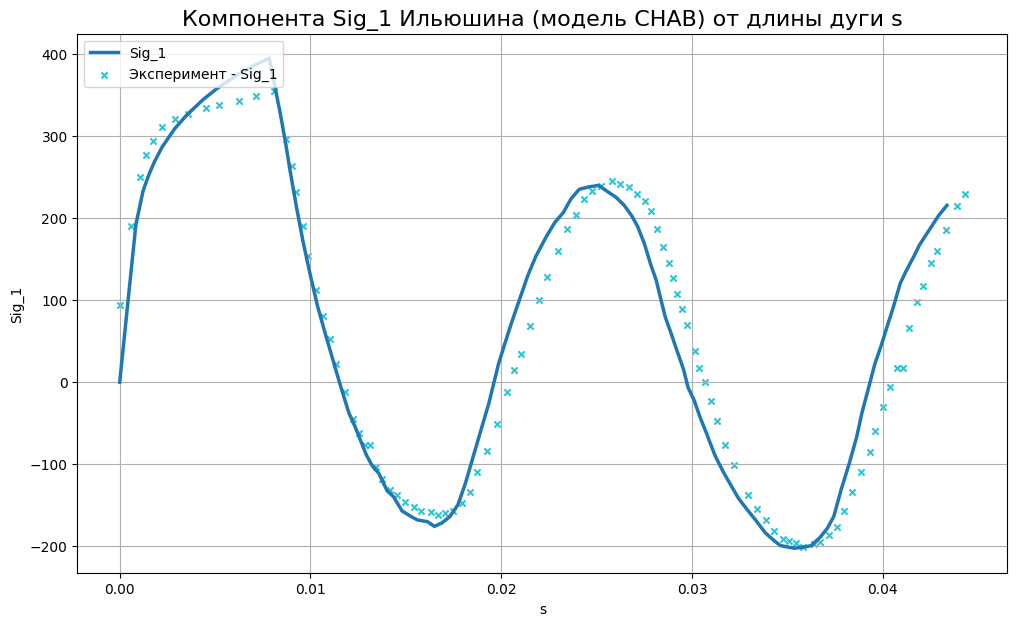

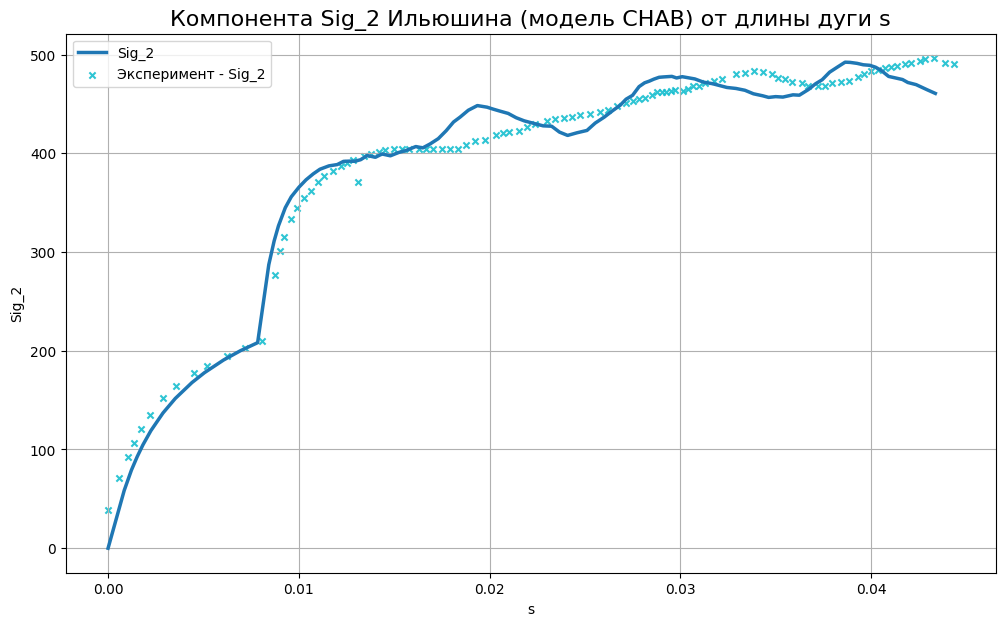

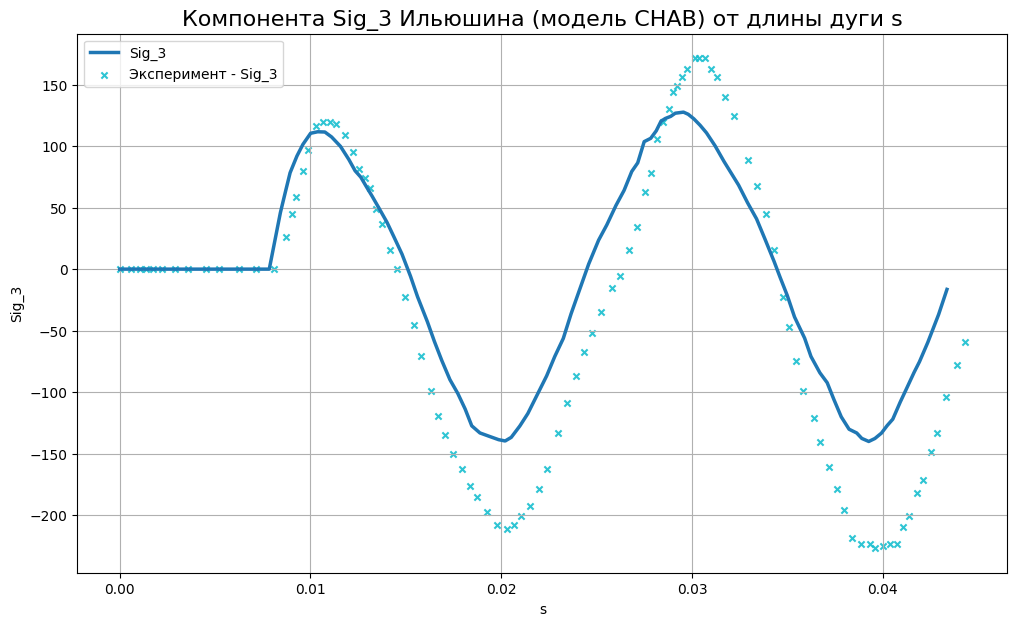

In [105]:
plot_xy(
    [(model_name, num_il)],
    "s",
    ["Sig_1"],
    f"Компонента Sig_1 Ильюшина (модель {model_name}) от длины дуги s",
    ("Эксперимент", exp_il),
    figsize=(12, 7),
)

plot_xy(
    [(model_name, num_il)],
    "s",
    ["Sig_2"],
    f"Компонента Sig_2 Ильюшина (модель {model_name}) от длины дуги s",
    ("Эксперимент", exp_il),
    figsize=(12, 7),
)

plot_xy(
    [(model_name, num_il)],
    "s",
    ["Sig_3"],
    f"Компонента Sig_3 Ильюшина (модель {model_name}) от длины дуги s",
    ("Эксперимент", exp_il),
    figsize=(12, 7),
)


In [106]:
df_metrics = ilushin_stress_metrics_at_experiment_times(
    real_experiment,
    numerical_experiment_chab,
    time_col="Time",
    compressible=False,
    direction="nearest",
)


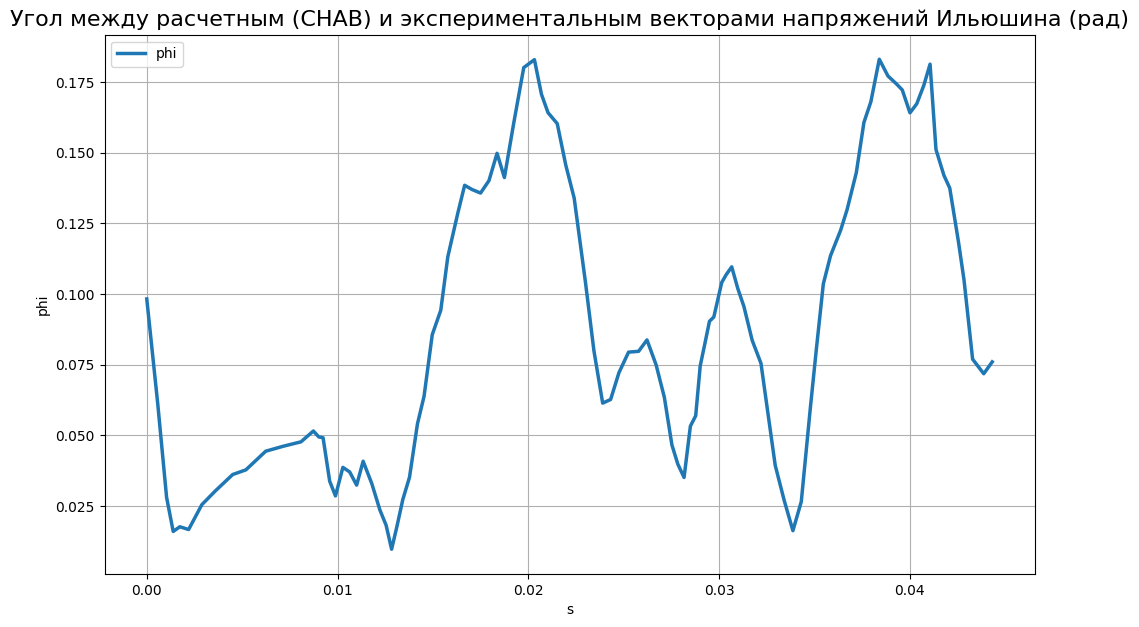

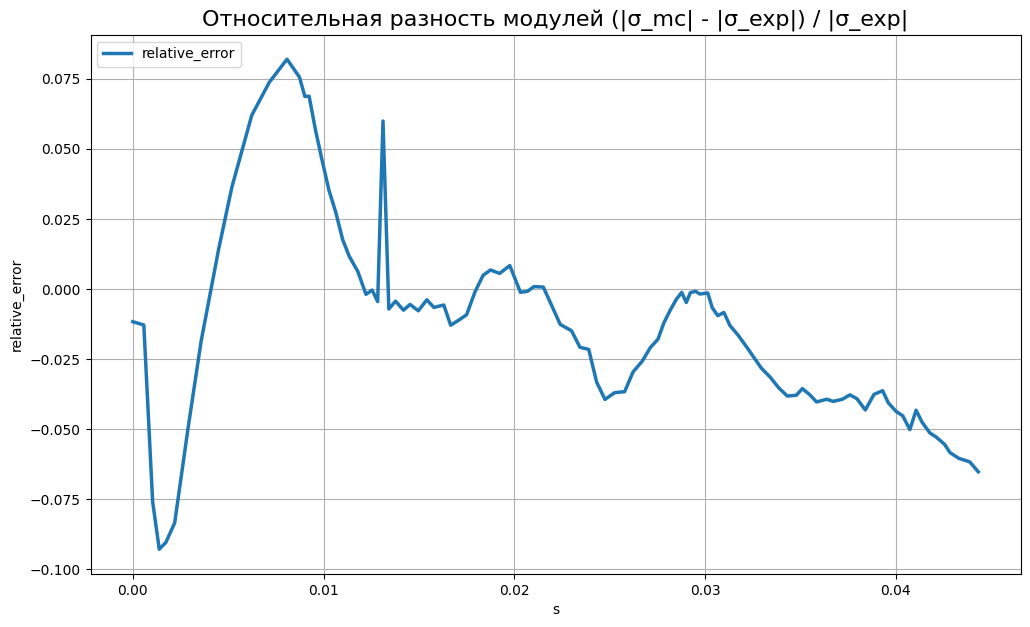

In [107]:
plot_xy(
    data_pairs=[(model_name, df_metrics)],
    x_col="s",
    y_cols=["phi"],
    title=f"Угол между расчетным ({model_name}) и экспериментальным векторами напряжений Ильюшина (рад)",
    figsize=(12, 7),
)

plot_xy(
    data_pairs=[(model_name, df_metrics)],
    x_col="s",
    y_cols=["relative_error"],
    title=f"Относительная разность модулей (|σ_mc| - |σ_exp|) / |σ_exp|",
    figsize=(12, 7),
)


#### Выводы по результатам сравнения (Ильюшин, см. графики выше)

1. **$\varepsilon_1^{Il}$ от $s$.** Фаза колебаний у расчёта (CHAB) и эксперимента согласована: экстремумы приходятся на близкие значения длины дуги $s$. По величине модель **систематически занижает** $\varepsilon_1^{Il}$; у опыта при $s=0$ заметен **ненулевой** уровень деформации при нуле в расчёте.

2. **$\varepsilon_2^{Il}$ от $s$.** Траектория близка к **линейному** росту с $s$; расчёт качественно повторяет опыт с **небольшим постоянным сдвигом вниз**. На расчётной кривой виден **излом наклона** в начале пути (около $s \approx 0{,}008$), после чего наклон стабилизируется.

3. **$\varepsilon_3^{Il}$ от $s$.** В первом цикле после выхода с нуля модель и опыт совпадают хорошо. На **втором и последующих** циклах нарастает **сдвиг по $s$**: экстремумы эксперимента смещены относительно расчётных (накопление фазового рассогласования вдоль дуги).

4. **$\sigma_1^{Il}$ от $s$.** В **первом** цикле амплитуды и форма близки. Далее расчётная кривая **опережает** эксперимент по фазе: пики и провалы модели достигаются при **меньших** $s$, чем у опыта.

5. **$\sigma_2^{Il}$ от $s$.** Общий тренд нагружения воспроизведён; у расчёта заметны **осцилляции**, тогда как экспериментальные точки образуют более **гладкую** кривую. К **концу** интервала по $s$ возможно расхождение (модель и опыт по-разному завершают участок пути).

6. **$\sigma_3^{Il}$ от $s$, угол $\varphi$ и относительная разность модулей.** По $\sigma_3^{Il}$ модель **недооценивает амплитуду**, особенно в **отрицательных** экстремумах; с ростом $s$ расхождение усиливается. Угол $\varphi$ между расчётным и экспериментальным векторами напряжений Ильюшина **непостоянен** вдоль $s$ (значимые пики порядка **~0,15–0,19 рад**). Относительная разность модулей $(|\boldsymbol{\sigma}^{\mathrm{числ}}|-|\boldsymbol{\sigma}^{\mathrm{эксп}}|)/|\boldsymbol{\sigma}^{\mathrm{эксп}}|$ меняется по траектории: есть **стартовые** провалы и пики, **узкий выброс** в отдельной точке $s$, интервал с ошибкой порядка нескольких процентов и **просадка** к концу пути (недооценка модуля расчётом).

Ниже — **второй этап** ($t > 14$): аппроксимация среднего напряжения, кривизна и кручение от $s$, затем уточнённый угол сближения на II этапе и **полный путь** для интенсивности и $\Theta$.


In [108]:
nu_path = r"nu.txt"
with open(nu_path, "r") as f:
    nu = float(f.read().strip())


In [109]:
split_time_exp = 14.0

df_exp_stage2 = real_experiment[real_experiment["Time"] > split_time_exp].copy()
df_exp_stage2.reset_index(drop=True, inplace=True)
df_exp_stage2["Sigma_Mean"] = (df_exp_stage2["S_ZZ"] + df_exp_stage2["S_TT"]) / 3.0

numerical_experiment_stage2 = numerical_experiment_chab[numerical_experiment_chab["Time"] > split_time_exp].copy()
numerical_experiment_stage2.reset_index(drop=True, inplace=True)

from core.calculations import calculate_stress_vector, ilushin_strain_arc_length_by_time

sig_1, sig_2, sig_3 = calculate_stress_vector(df_exp_stage2)
df_exp_stage2["Sig_1"] = sig_1
df_exp_stage2["Sig_2"] = sig_2
df_exp_stage2["Sig_3"] = sig_3

sig_1, sig_2, sig_3 = calculate_stress_vector(numerical_experiment_stage2)
numerical_experiment_stage2["Sig_1"] = sig_1
numerical_experiment_stage2["Sig_2"] = sig_2
numerical_experiment_stage2["Sig_3"] = sig_3

# Длина дуги в пространстве Ильюшина только по точкам II этапа (накопление от начала этапа)
s_e = ilushin_strain_arc_length_by_time(df_exp_stage2, time_col="Time", compressible=False)
df_exp_stage2 = df_exp_stage2.merge(s_e[["Time", "s"]], on="Time", how="inner")
df_exp_stage2.rename(columns={"s": "s_stage2"}, inplace=True)

s_n = ilushin_strain_arc_length_by_time(numerical_experiment_stage2, time_col="Time", compressible=True)
numerical_experiment_stage2 = numerical_experiment_stage2.merge(s_n[["Time", "s"]], on="Time", how="inner")
numerical_experiment_stage2.rename(columns={"s": "s_stage2"}, inplace=True)

df_exp_stage2["s"] = df_exp_stage2["s_stage2"]
numerical_experiment_stage2["s"] = numerical_experiment_stage2["s_stage2"]


### Аппроксимация среднего напряжения (II этап, $t > 14$)

На втором этапе среднее напряжение $\sigma_{\mathrm{mean}} = (\sigma_{zz}+\sigma_{\theta\theta})/3$ (в данных — из $S_{ZZ}$, $S_{TT}$) аппроксимируется моделью **гармоника + линейный тренд** (`VolumetricModel`) **как функция длины дуги** $s$ — накопленная дуга в пространстве деформаций Ильюшина **вдоль этапа** (`s_stage2`):

$$\sigma_{\mathrm{mean}}(s) \approx p\cos(\omega s + \phi) + b_1 s + b_2.$$

Аналитические производные $\mathrm{d}\sigma_{\mathrm{mean}}/\mathrm{d}s$ далее используются в `GeometricProperties` для кривизны/кручения и для гладкой касательной при расчёте угла сближения на II этапе.


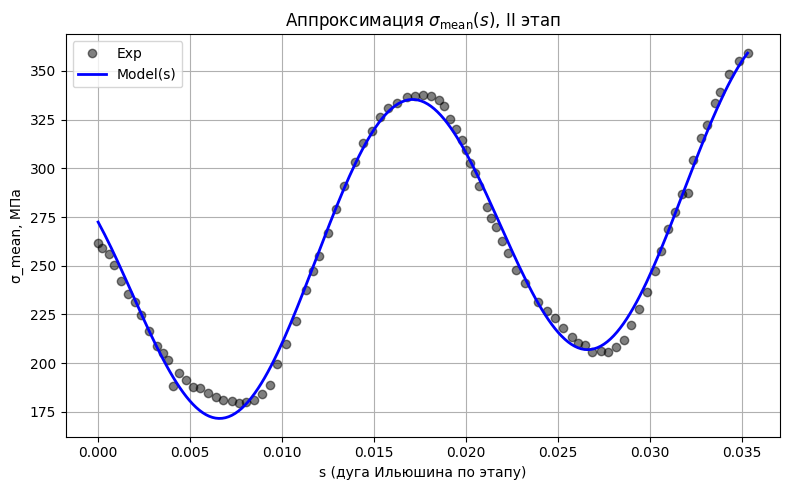

Параметры: [7.27804390e+01 3.14010639e+02 9.91886227e-01 1.76315898e+03
 2.32604657e+02]


In [110]:
from core.derivatives.stress_approximation import VolumetricModel
import matplotlib.pyplot as plt
import numpy as np

sig_vals = df_exp_stage2["Sigma_Mean"].values
s_vals = df_exp_stage2["s_stage2"].values

vol_model_s = VolumetricModel()
s_span = s_vals.max() - s_vals.min()
w_guess_s = (4 * np.pi) / max(s_span, 1e-9)
params_s = vol_model_s.fit(s_vals, sig_vals, guess_w=w_guess_s)

plt.figure(figsize=(8, 5))
plt.plot(s_vals, sig_vals, "ko", alpha=0.5, label="Exp")
s_grid_plot = np.linspace(s_vals.min(), s_vals.max(), 200)
plt.plot(s_grid_plot, vol_model_s.predict(s_grid_plot), "b-", lw=2, label="Model(s)")
plt.title(r"Аппроксимация $\sigma_{\mathrm{mean}}(s)$, II этап")
plt.xlabel("s (дуга Ильюшина по этапу)")
plt.ylabel("σ_mean, МПа")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("Параметры:", params_s)


### Кривизна и кручение от длины дуги $s$ (II этап)

Используется идеальная винтовая траектория в пространстве Ильюшина плюс поправка на объём (производные $\Delta$ по $s$ из аппроксимации **$\sigma_{\mathrm{mean}}(s)$**).

$$\varkappa = \frac{|\dot{\bar{\varepsilon}} \times \ddot{\bar{\varepsilon}}|}{|\dot{\bar{\varepsilon}}|^3}, \qquad
\tau = \frac{(\dot{\bar{\varepsilon}} \times \ddot{\bar{\varepsilon}}) \cdot \dddot{\bar{\varepsilon}}}{|\dot{\bar{\varepsilon}} \times \ddot{\bar{\varepsilon}}|^2}.$$


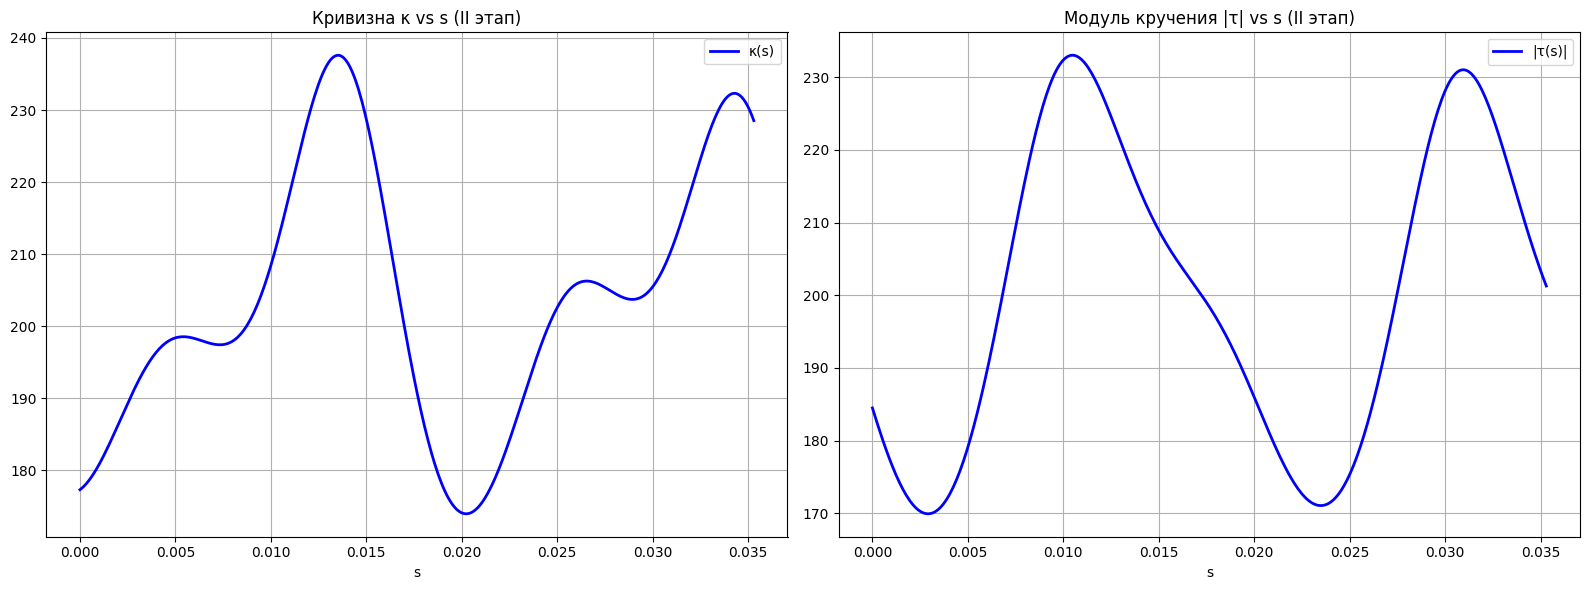

In [111]:
import numpy as np
import matplotlib.pyplot as plt
from core.derivatives.stress_approximation import GeometricProperties

geom = GeometricProperties(vol_model_s, E=2.05e5, nu=nu, c=0.0025, a=0.0157)
s_fine = np.linspace(s_vals.min(), s_vals.max(), 400)
kappa_s, tau_s = geom.compute_geometry(s_fine)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.plot(s_fine, kappa_s, "b-", lw=2, label="κ(s)")
ax1.set_title("Кривизна κ vs s (II этап)")
ax1.set_xlabel("s")
ax1.grid(True)
ax1.legend()

ax2.plot(s_fine, np.abs(tau_s), "b-", lw=2, label="|τ(s)|")
ax2.set_title("Модуль кручения |τ| vs s (II этап)")
ax2.set_xlabel("s")
ax2.grid(True)
ax2.legend()
plt.tight_layout()
plt.show()


### Анализ векторных и скалярных свойств (II этап, поточечно)

1. **Эксперимент:** `compressible=False` (нет $\varepsilon_{rr}$ в данных).
2. **Расчёт ANSYS:** `compressible=True` при построении дуги для численного ряда.
3. **Угол сближения (эксперимент):** производные $\mathrm d\varepsilon^{\mathrm{Il}}/\mathrm ds$ по **только экспериментальным** компонентам $\varepsilon^{\mathrm{Il}}$ на II этапе — `np.gradient` по дуге $s_{\mathrm{stage2}}$ (как в `analysis.ipynb`), **без** `GeometricProperties` / аппроксимации $\sigma_{\mathrm{mean}}$.
4. **Угол (ANSYS, II этап):** гладкая касательная из `GeometricProperties.get_derivatives(s_{\mathrm{stage2}})` с `vol_model_s`, подогнанной по опыту на II этапе.
5. **Знаки:** инверсия $S_{TZ}$, $EPTO_{TZ}$ и $\mathrm{Sig}_3$ для согласования с экспериментом (ячейка ниже).



In [112]:
import pandas as pd
import numpy as np
from core.calculations import calculate_theta, calculate_ilushin_strain_vector
from core.derivatives.stress_approximation import GeometricProperties

real_experiment["S_TZ"] = -real_experiment["S_TZ"]
real_experiment["EPTO_TZ"] = -real_experiment["EPTO_TZ"]
df_exp_stage2["Sig_3"] = -df_exp_stage2["Sig_3"]
numerical_experiment_stage2["Sig_3"] = -numerical_experiment_stage2["Sig_3"]

approx = GeometricProperties(vol_model_s, E=2.05e5, nu=nu, c=0.0025, a=0.0157)
v_ans = approx.get_derivatives(numerical_experiment_stage2["s_stage2"].values)

df_ans_theta_calc = pd.DataFrame(
    {
        "Sig_1": numerical_experiment_stage2["Sig_1"],
        "Sig_2": numerical_experiment_stage2["Sig_2"],
        "Sig_3": numerical_experiment_stage2["Sig_3"],
        "dEps_1_approx": v_ans[0],
        "dEps_2_approx": v_ans[1],
        "dEps_3_approx": v_ans[2],
    }
)

il_exp2 = calculate_ilushin_strain_vector(df_exp_stage2, compressible=False)
df_exp_stage2 = df_exp_stage2.merge(
    il_exp2[["Time", "Eps_1", "Eps_2", "Eps_3"]], on="Time", how="inner"
)
df_exp_s2 = df_exp_stage2.sort_values("s_stage2", kind="mergesort").reset_index(drop=True)
E_exp = df_exp_s2[["Eps_1", "Eps_2", "Eps_3"]].to_numpy(dtype=float)
s_exp = df_exp_s2["s_stage2"].to_numpy(dtype=float)
d_exp = np.gradient(E_exp, s_exp, axis=0, edge_order=2)
df_exp_theta_sorted = pd.DataFrame(
    {
        "Sig_1": df_exp_s2["Sig_1"].values,
        "Sig_2": df_exp_s2["Sig_2"].values,
        "Sig_3": df_exp_s2["Sig_3"].values,
        "dEps_1_grad": d_exp[:, 0],
        "dEps_2_grad": d_exp[:, 1],
        "dEps_3_grad": d_exp[:, 2],
    }
)
df_exp_s2["Theta_vs_ans"] = calculate_theta(df_exp_theta_sorted, deriv_suffix="_grad")
df_exp_stage2 = df_exp_stage2.drop(columns=["Theta_vs_ans"], errors="ignore").merge(
    df_exp_s2[["Time", "Theta_vs_ans"]], on="Time", how="left"
)

numerical_experiment_stage2["Theta_Approx"] = calculate_theta(df_ans_theta_calc, deriv_suffix="_approx")



### Интенсивность и угол сближения в пространстве Ильюшина

**Интенсивность напряжений** понимается как модуль вектора напряжений Ильюшина. Компоненты этого вектора получают из табличных данных: для эксперимента используются измеренные напряжения, для сравнения — напряжения из конечно-элементного расчёта (ANSYS) для выбранной модели материала.

**Угол сближения** — угол между вектором напряжений и вектором скорости изменения деформаций вдоль траектории в пространстве Ильюшина (арккосинус от нормированного скалярного произведения).

**Эксперимент (Theta Experiment):** скорость деформаций задаётся **только по данным опыта**: компоненты $\varepsilon^{\mathrm{Il}}$ из измеренных полных деформаций, производные по глобальной дуге $s$ — **`np.gradient` вдоль $s$** (аналогично `analysis.ipynb`). Аппроксимация $\sigma_{\mathrm{mean}}(s)$ для касательной **не используется**.

**ANSYS, зелёная кривая:** на **I этапе** ($t \le 14$) касательная — **`np.gradient`** по численным $\varepsilon^{\mathrm{Il}}$ вдоль глобальной $s$; на **II этапе** — гладкая касательная из **аппроксимации** $\sigma_{\mathrm{mean}}(s)$ только по II этапу + винтовая кинематика (`GeometricProperties`), т.к. вид функции на I этапе заранее не фиксируется.

**ANSYS, пунктир:** производные по $s$ **конечными разностями** между соседними точками вдоль накопленной дуги (диагностика чувствительности к дискретизации).



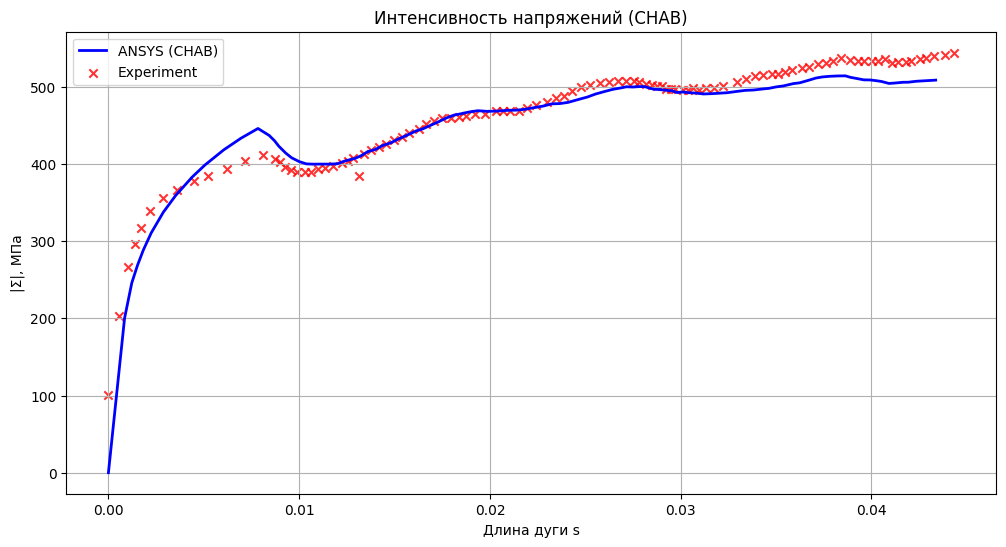

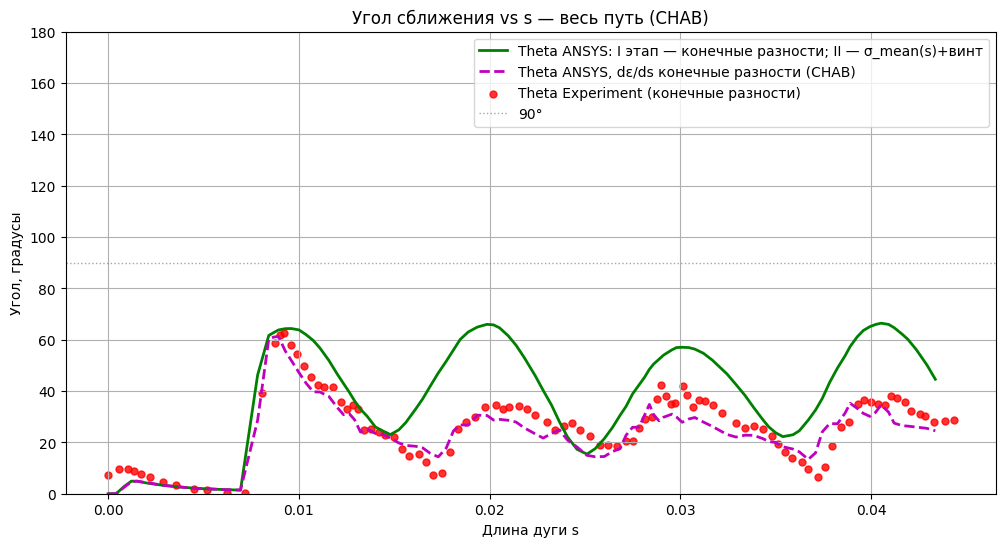

In [115]:
# Весь процесс нагружения: |Σ| и Θ vs глобальной дуги s (от начала эксперимента)
# Theta Exp: только данные опыта — np.gradient(Eps^Il) по s (как в analysis.ipynb).
# Theta ANSYS «аппроксимация»: только II этап (t > split_time_exp); на I этапе — np.gradient по тем же данным CHAB.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from core.calculations import (
    ilushin_strain_arc_length_by_time,
    calculate_stress_vector,
    calculate_theta,
    calculate_ilushin_strain_vector,
)
from core.derivatives.stress_approximation import GeometricProperties, VolumetricModel


def _d_eps_ds_along_s(eps: np.ndarray, s_arr: np.ndarray) -> np.ndarray:
    """dε/ds по дуге: центральные разности внутри, односторонние на концах."""
    n = len(eps)
    out = np.zeros(n, dtype=float)
    for i in range(n):
        if i == 0:
            out[i] = (eps[i + 1] - eps[i]) / (s_arr[i + 1] - s_arr[i])
        elif i == n - 1:
            out[i] = (eps[i] - eps[i - 1]) / (s_arr[i] - s_arr[i - 1])
        else:
            out[i] = (eps[i + 1] - eps[i - 1]) / (s_arr[i + 1] - s_arr[i - 1])
    return out


re = real_experiment.copy()
sg_e = ilushin_strain_arc_length_by_time(re, time_col="Time", compressible=False)
re = re.merge(sg_e[["Time", "s"]], on="Time", how="inner")
re.rename(columns={"s": "s_il"}, inplace=True)
re["Sigma_Mean"] = (re["S_ZZ"] + re["S_TT"]) / 3.0

nc = numerical_experiment_chab.copy()
sg_n = ilushin_strain_arc_length_by_time(nc, time_col="Time", compressible=True)
nc = nc.merge(sg_n[["Time", "s"]], on="Time", how="inner")
nc.rename(columns={"s": "s_il"}, inplace=True)
nc["Sigma_Mean"] = (nc["S_ZZ"] + nc["S_TT"]) / 3.0

s1, s2, s3 = calculate_stress_vector(re)
re["Sig_1"], re["Sig_2"], re["Sig_3"] = s1.values, s2.values, s3.values
n1, n2, n3 = calculate_stress_vector(nc)
nc["Sig_1"], nc["Sig_2"], nc["Sig_3"] = n1.values, n2.values, n3.values

il_re = calculate_ilushin_strain_vector(re, compressible=False)
re = re.merge(il_re[["Time", "Eps_1", "Eps_2", "Eps_3"]], on="Time", how="inner")
re_s = re.sort_values("s_il", kind="mergesort").reset_index(drop=True)
E_re = re_s[["Eps_1", "Eps_2", "Eps_3"]].to_numpy(dtype=float)
s_re = re_s["s_il"].to_numpy(dtype=float)
d_re = np.gradient(E_re, s_re, axis=0, edge_order=2)
df_te = pd.DataFrame(
    {
        "Sig_1": re_s["Sig_1"].values,
        "Sig_2": re_s["Sig_2"].values,
        "Sig_3": re_s["Sig_3"].values,
        "dEps_1_grad": d_re[:, 0],
        "dEps_2_grad": d_re[:, 1],
        "dEps_3_grad": d_re[:, 2],
    }
)
re_s["Theta"] = calculate_theta(df_te, deriv_suffix="_grad")
re = re.drop(columns=["Theta"], errors="ignore").merge(re_s[["Time", "Theta"]], on="Time", how="left")

nc_s = nc.sort_values("s_il", kind="mergesort").reset_index(drop=True)
nc_s = nc_s.merge(
    numerical_experiment_stage2[["Time", "s_stage2"]], on="Time", how="left"
)

il_eps = calculate_ilushin_strain_vector(nc_s, compressible=True)
nc_s = nc_s.merge(il_eps[["Time", "Eps_1", "Eps_2", "Eps_3"]], on="Time", how="inner")
nc_s = nc_s.sort_values("s_il", kind="mergesort").reset_index(drop=True)

s_arr = nc_s["s_il"].to_numpy(dtype=float)
E_num = nc_s[["Eps_1", "Eps_2", "Eps_3"]].to_numpy(dtype=float)
d_num_grad = np.gradient(E_num, s_arr, axis=0, edge_order=2)

num2 = numerical_experiment_stage2.copy()
if "Sigma_Mean" not in num2.columns:
    num2["Sigma_Mean"] = (num2["S_ZZ"] + num2["S_TT"]) / 3.0
vm_n = VolumetricModel()
vm_n.fit(num2["s_stage2"].values, num2["Sigma_Mean"].values)
ap_n = GeometricProperties(vm_n, E=2.05e5, nu=nu, c=0.0025, a=0.0157)

mask2 = (nc_s["Time"] > split_time_exp).to_numpy()
s2 = nc_s.loc[mask2, "s_stage2"].to_numpy(dtype=float)
vn_blend = d_num_grad.copy()
if np.any(mask2):
    vn_s2 = ap_n.get_derivatives(s2)
    vn_blend[mask2, 0] = vn_s2[0]
    vn_blend[mask2, 1] = vn_s2[1]
    vn_blend[mask2, 2] = vn_s2[2]

df_tn = pd.DataFrame(
    {
        "Sig_1": nc_s["Sig_1"].values,
        "Sig_2": nc_s["Sig_2"].values,
        "Sig_3": nc_s["Sig_3"].values,
        "dEps_1_approx": vn_blend[:, 0],
        "dEps_2_approx": vn_blend[:, 1],
        "dEps_3_approx": vn_blend[:, 2],
    }
)
nc_s["Theta"] = calculate_theta(df_tn, deriv_suffix="_approx")

e1 = nc_s["Eps_1"].to_numpy(dtype=float)
e2 = nc_s["Eps_2"].to_numpy(dtype=float)
e3 = nc_s["Eps_3"].to_numpy(dtype=float)

df_fd = pd.DataFrame(
    {
        "Sig_1": nc_s["Sig_1"].values,
        "Sig_2": nc_s["Sig_2"].values,
        "Sig_3": nc_s["Sig_3"].values,
        "dEps_1_fd": _d_eps_ds_along_s(e1, s_arr),
        "dEps_2_fd": _d_eps_ds_along_s(e2, s_arr),
        "dEps_3_fd": _d_eps_ds_along_s(e3, s_arr),
    }
)
nc_s["Theta_fd"] = calculate_theta(df_fd, deriv_suffix="_fd")

re["S_EQV"] = np.sqrt(re["Sig_1"] ** 2 + re["Sig_2"] ** 2 + re["Sig_3"] ** 2)
nc_s["S_EQV"] = np.sqrt(nc_s["Sig_1"] ** 2 + nc_s["Sig_2"] ** 2 + nc_s["Sig_3"] ** 2)

plt.figure(figsize=(12, 6))
plt.plot(nc_s["s_il"], nc_s["S_EQV"], "b-", label=f"ANSYS ({model_name})", lw=2)
plt.scatter(re["s_il"], re["S_EQV"], c="r", marker="x", label="Experiment", alpha=0.8)
plt.title(f"Интенсивность напряжений ({model_name})")
plt.xlabel("Длина дуги s")
plt.ylabel("|Σ|, МПа")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(
    nc_s["s_il"],
    nc_s["Theta"],
    "g-",
    label="Theta ANSYS: I этап — конечные разности; II — σ_mean(s)+винт",
    lw=2,
)
plt.plot(
    nc_s["s_il"],
    nc_s["Theta_fd"],
    "m--",
    label=f"Theta ANSYS, dε/ds конечные разности ({model_name})",
    lw=2,
)
plt.scatter(
    re["s_il"],
    re["Theta"],
    c="r",
    marker="o",
    s=25,
    label="Theta Experiment (конечные разности)",
    alpha=0.8,
)
plt.title(f"Угол сближения vs s — весь путь ({model_name})")
plt.xlabel("Длина дуги s")
plt.ylabel("Угол, градусы")
plt.axhline(90, color="gray", ls=":", lw=1, alpha=0.7, label="90°")
plt.legend()
plt.grid(True)
plt.ylim(0, 180)
plt.show()



### Выводы: интенсивность $|\Sigma|$ и угол сближения $\Theta$ на всём пути (CHAB)

**Интенсивность $|\Sigma|(s)$.** В начале пути расчёт и опыт расходятся по уровню (в т.ч. старт с нуля у ANSYS при ненулевой интенсивности в эксперименте — следствие разных начальных/пограничных условий и представления данных). Далее кривые качественно согласованы, но у ANSYS заметна **волнообразность**, тогда как опыт ближе к **монотонному** росту с шумом; к концу дуги $s$ интенсивность эксперимента может **превосходить** расчёт. Это согласуется с рассогласованием модулей напряжений Ильюшина по траектории (см. график относительной ошибки выше).

**Угол сближения $\Theta(s)$.** На графике виден **резкий переход** около $s \approx 0{,}007$: до него угол у расчётных кривых ANSYS (и частично у опыта) **близок к нулю**, после — **скачкообразный рост** к величинам порядка $60^\circ$ и дальше колебательный ход. Такой излом согласуется со **сшивкой постановок** на границе этапов: на I этапе касательная к траектории в пространстве Ильюшина задаётся **численно** (`np.gradient` по данным CHAB), на II этапе для **зелёной** линии подключается **модельная** касательная (аппроксимация $\sigma_{\mathrm{mean}}(s)$ по II этапу + винтовая кинематика). В точке сшивки направление «скорости» деформаций меняется с **оценки по фактической дискретной траектории** на **заданную аналитически** — это неизбежно даёт **производный** скачок на кривой $\Theta$, если модельная касательная не совпадает с градиентом по тем же точкам.

**Эксперимент** на графике строится **только из данных опыта**: $\mathrm{d}\boldsymbol{\varepsilon}^{\mathrm{Il}}/\mathrm{d}s$ — **`np.gradient`** вдоль глобальной дуги $s$. На **второй фазе** пути ($s$ после указанного излома) точки опыта по **уровню и фазе колебаний** заметно **ближе к пурпурной линии** (конечные разности по шагам ANSYS вдоль той же дуги), чем к **зелёной**. Иначе говоря, **дискретная** касательная к траектории деформаций из FE **лучше согласуется** с касательной, восстановленной по эксперименту, чем **гладкая** касательная из схемы «$\sigma_{\mathrm{mean}}(s)$ + винт». Зелёная кривая на длинном участке II этапа **систематически завышает** $\Theta$ относительно опыта (пики около $60^\circ$ у зелёной при том, что у опыта и пунктира максимумы чаще укладываются примерно в $30^\circ$–$40^\circ$). Это указывает на то, что **аналитическая постановка касательной на II этапе** не полностью отражает **фактическое** направление $\mathrm{d}\boldsymbol{\varepsilon}^{\mathrm{Il}}/\mathrm{d}s$ ни в расчёте (сравнение зелёной и пурпурной), ни в эксперименте.

**Почему пурпурная линия в начале пути низкая, а после скачка ближе к опыту?** (1) На **малых** $s$ конечная разность по **первым** шагам даёт направление **почти сонаправленное** с $\boldsymbol{\sigma}^{\mathrm{Il}}$ (малый угол между векторами), тогда как после накопления дуги направление приращения **отклоняется** — угол растёт. (2) **Пурпурная** и **зелёная** ветви ANSYS на II этапе используют **разные** определения $\mathrm{d}\boldsymbol{\varepsilon}^{\mathrm{Il}}/\mathrm{d}s$ (ломаная vs модельный винт); расхождение между ними — мера **неадекватности замены** реальной касательной гладкой моделью. (3) Шум и погрешности **экспериментальных** $\varepsilon^{\mathrm{Il}}$ при `np.gradient` дают разброс точек; тем не менее **средний тренд** опыта на II этапе последовательнее поддерживает **пурпурную** ветвь, а не зелёную.

**Итог по углу:** для **сопоставления с опытом** на II этапе разумнее ориентироваться на **касательную, восстановленную по данным** (у опыта — `np.gradient`; у ANSYS — как минимум сопоставлять с **конечными разностями** по той же дискретной траектории). **Зелёная** линия полезна как **модельный** вариант с явной аппроксимацией $\sigma_{\mathrm{mean}}$ и винтом, но она **не дублирует** ни дискретную кинематику FE, ни экспериментальную оценку $\Theta$ на колебательном участке.

